# Correlations between soundscape indices



In [25]:
"============== LOAD LIBRARIES ============"

library(data.table)
library(corrplot)


[1] "============== LOAD LIBRARIES ============"

In [26]:
"============== OPTIONS ============"
CORRELATION_TYPE = 'spearman'

[1] "============== OPTIONS ============"

In [27]:
"============== IMPORT CSV ============"
#import data
data = fread("../results/data_species_balanced.csv")

# Extract the acoustic index only
data_index = data[,c(2:61)]

[1] "============== IMPORT CSV ============"

[1] "================================="
[1] "The most correlated index are "
            indice1         indice2 correlation_r        pvalue
1               ZCR            NDSI     0.8506661  0.000000e+00
2               ZCR             rBA     0.8506661  3.154355e-47
3              VARt            LEQt     0.9999998  5.396383e-73
4              VARt            BGNt     0.8997354  3.876592e-42
5              VARt               M     0.8997354 1.106416e-178
6              VARt           MEANf     0.8666046 1.146860e-191
7              VARt            VARf     0.9743727  0.000000e+00
8              VARt            LEQf     0.9746405  8.253019e-59
9              VARt            BGNf     0.8740932  9.753949e-40
10             VARt             ROU     0.9671034  0.000000e+00
11            KURTt            SNRt     0.8903833  4.530822e-19
12            KURTt              Ht    -0.9187299  4.174931e-74
13            KURTt        ACTtMean     0.9390377  6.016036e-24
14            KURTt        

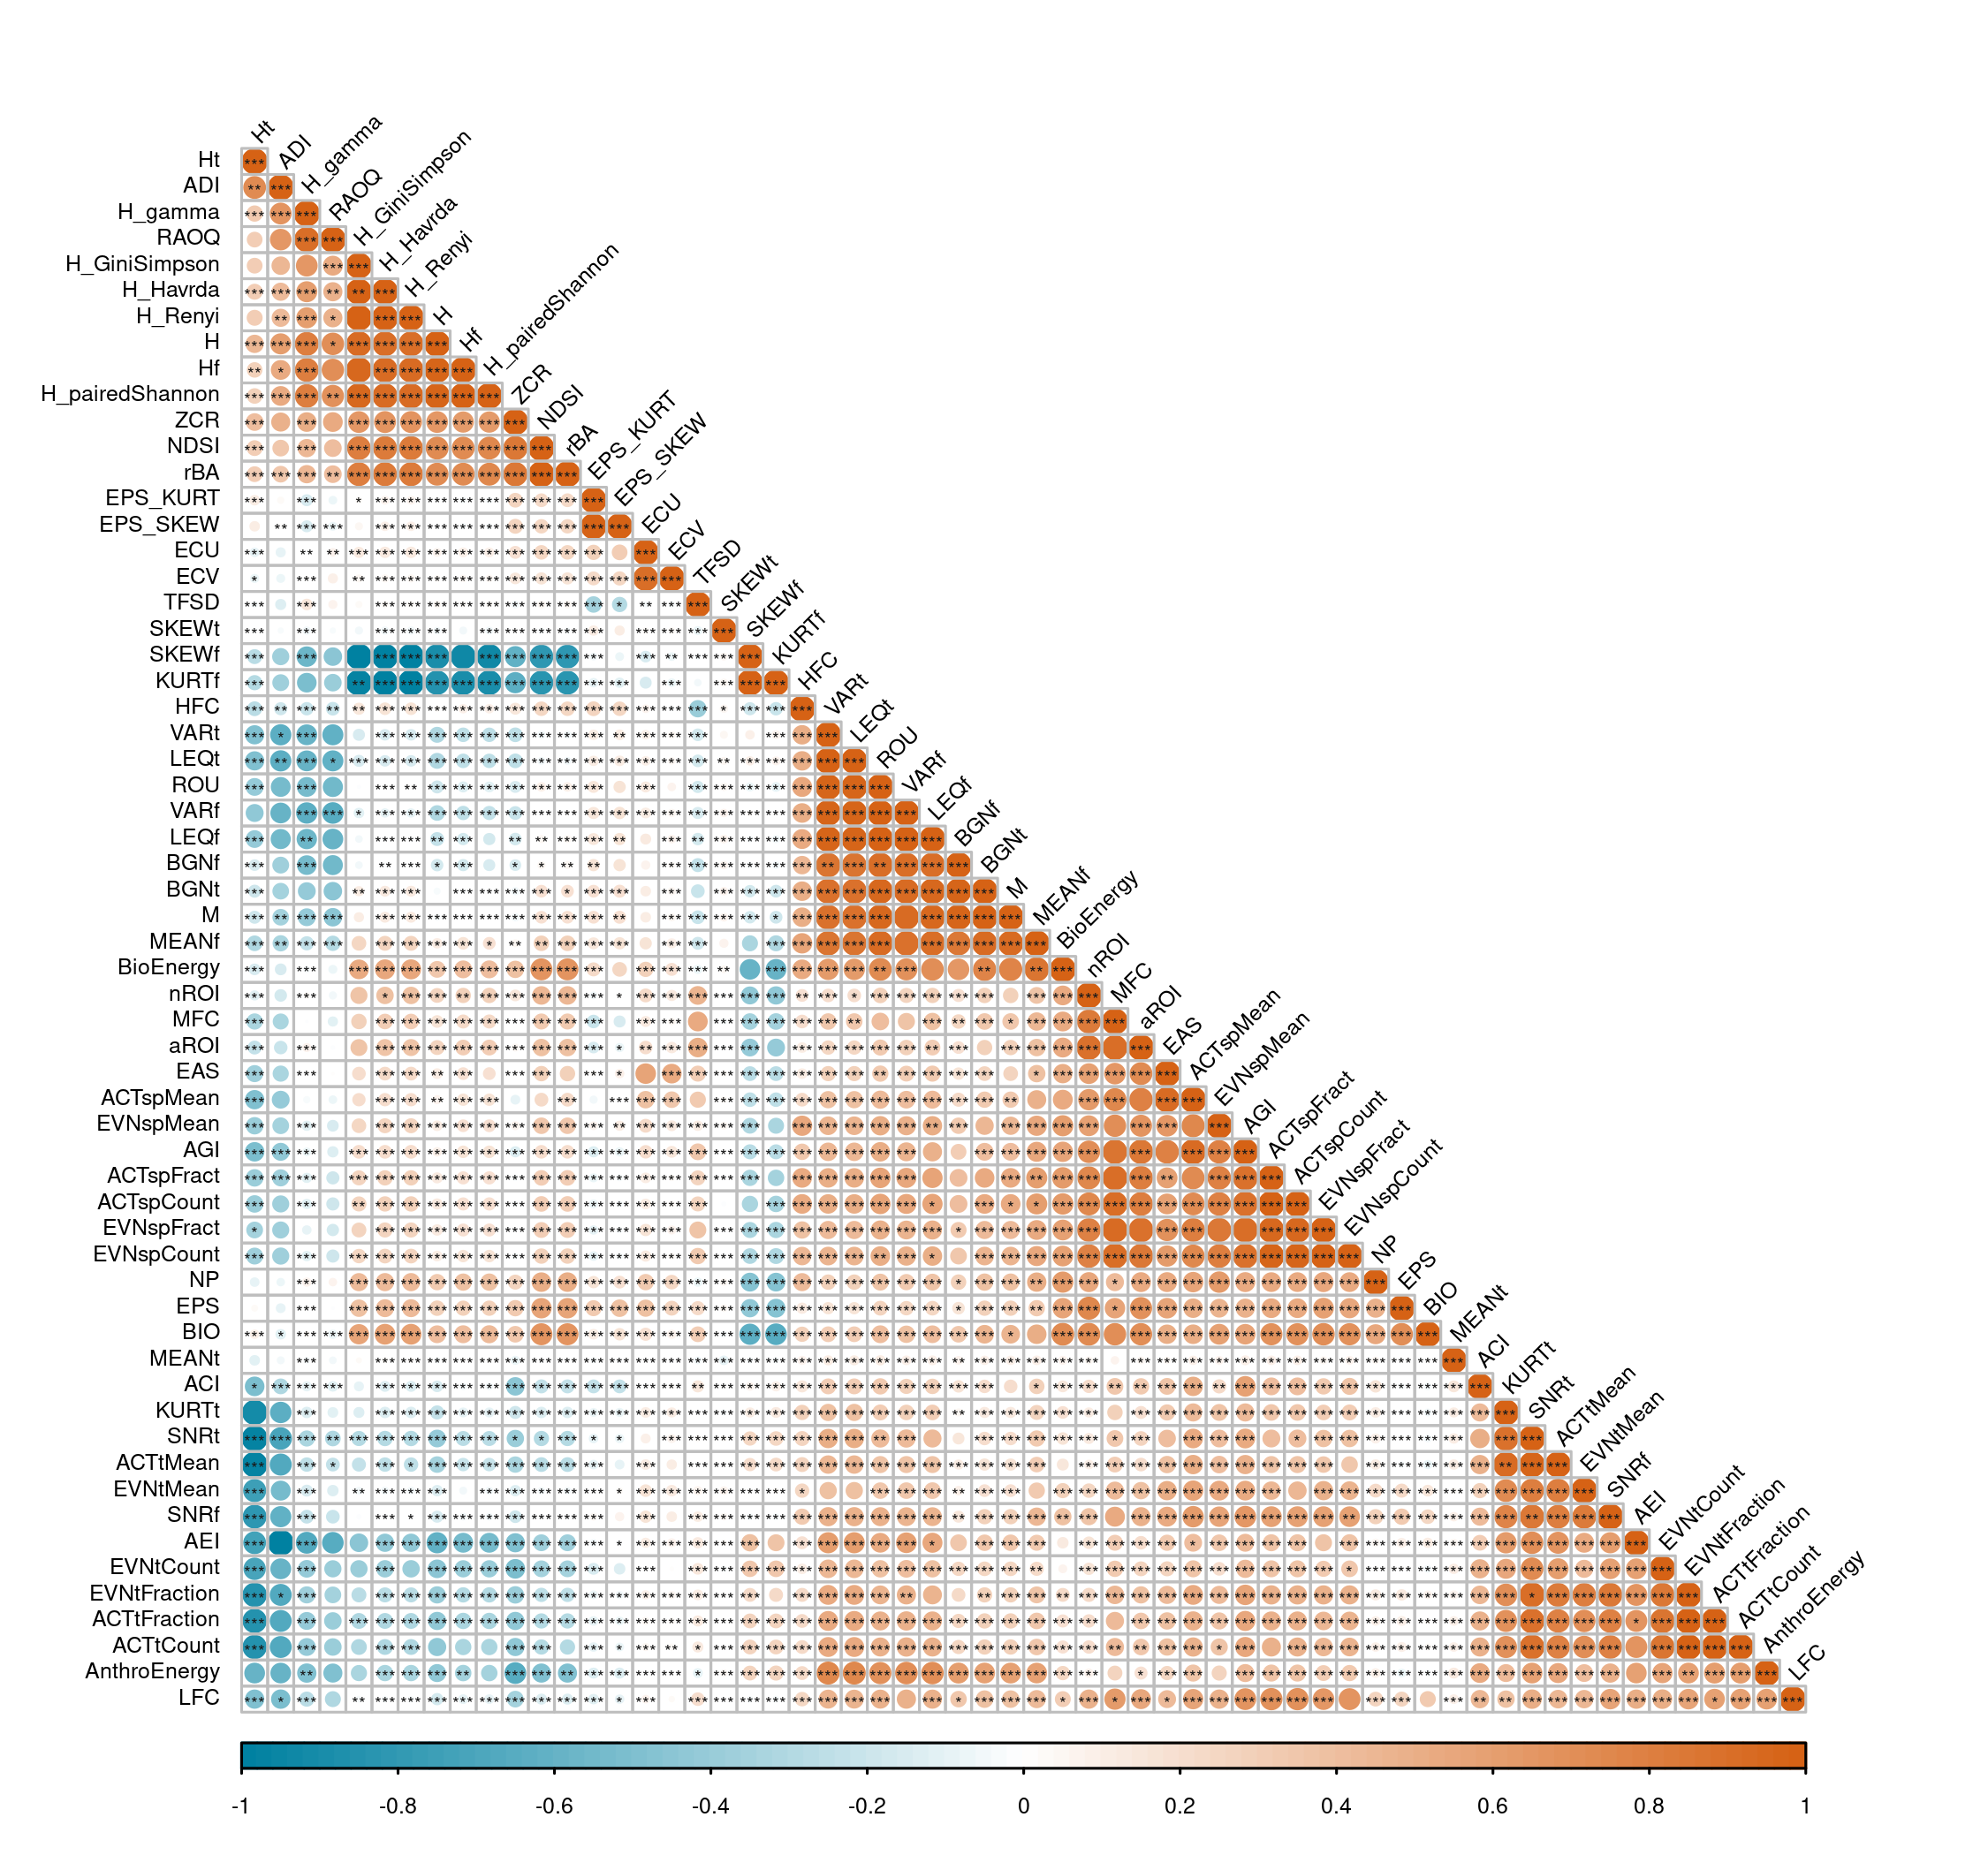

In [28]:
# Resize the figure 
options(repr.plot.width = 7.5, repr.plot.height = 7, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index, method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.4, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 45,
      tl.cex = 0.5,
      cl.ratio = 0.075,
      cl.cex = 0.5
)

# Find the indices of correlations with abs(R) > 0.75 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.75 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
      indice1 = rownames(cor_matrix)[significant_idx[, 1]],
      indice2 = colnames(cor_matrix)[significant_idx[, 2]],
      correlation_r = cor_matrix[significant_idx],
      pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)


Find the correlation between the indices that correlate with species richness

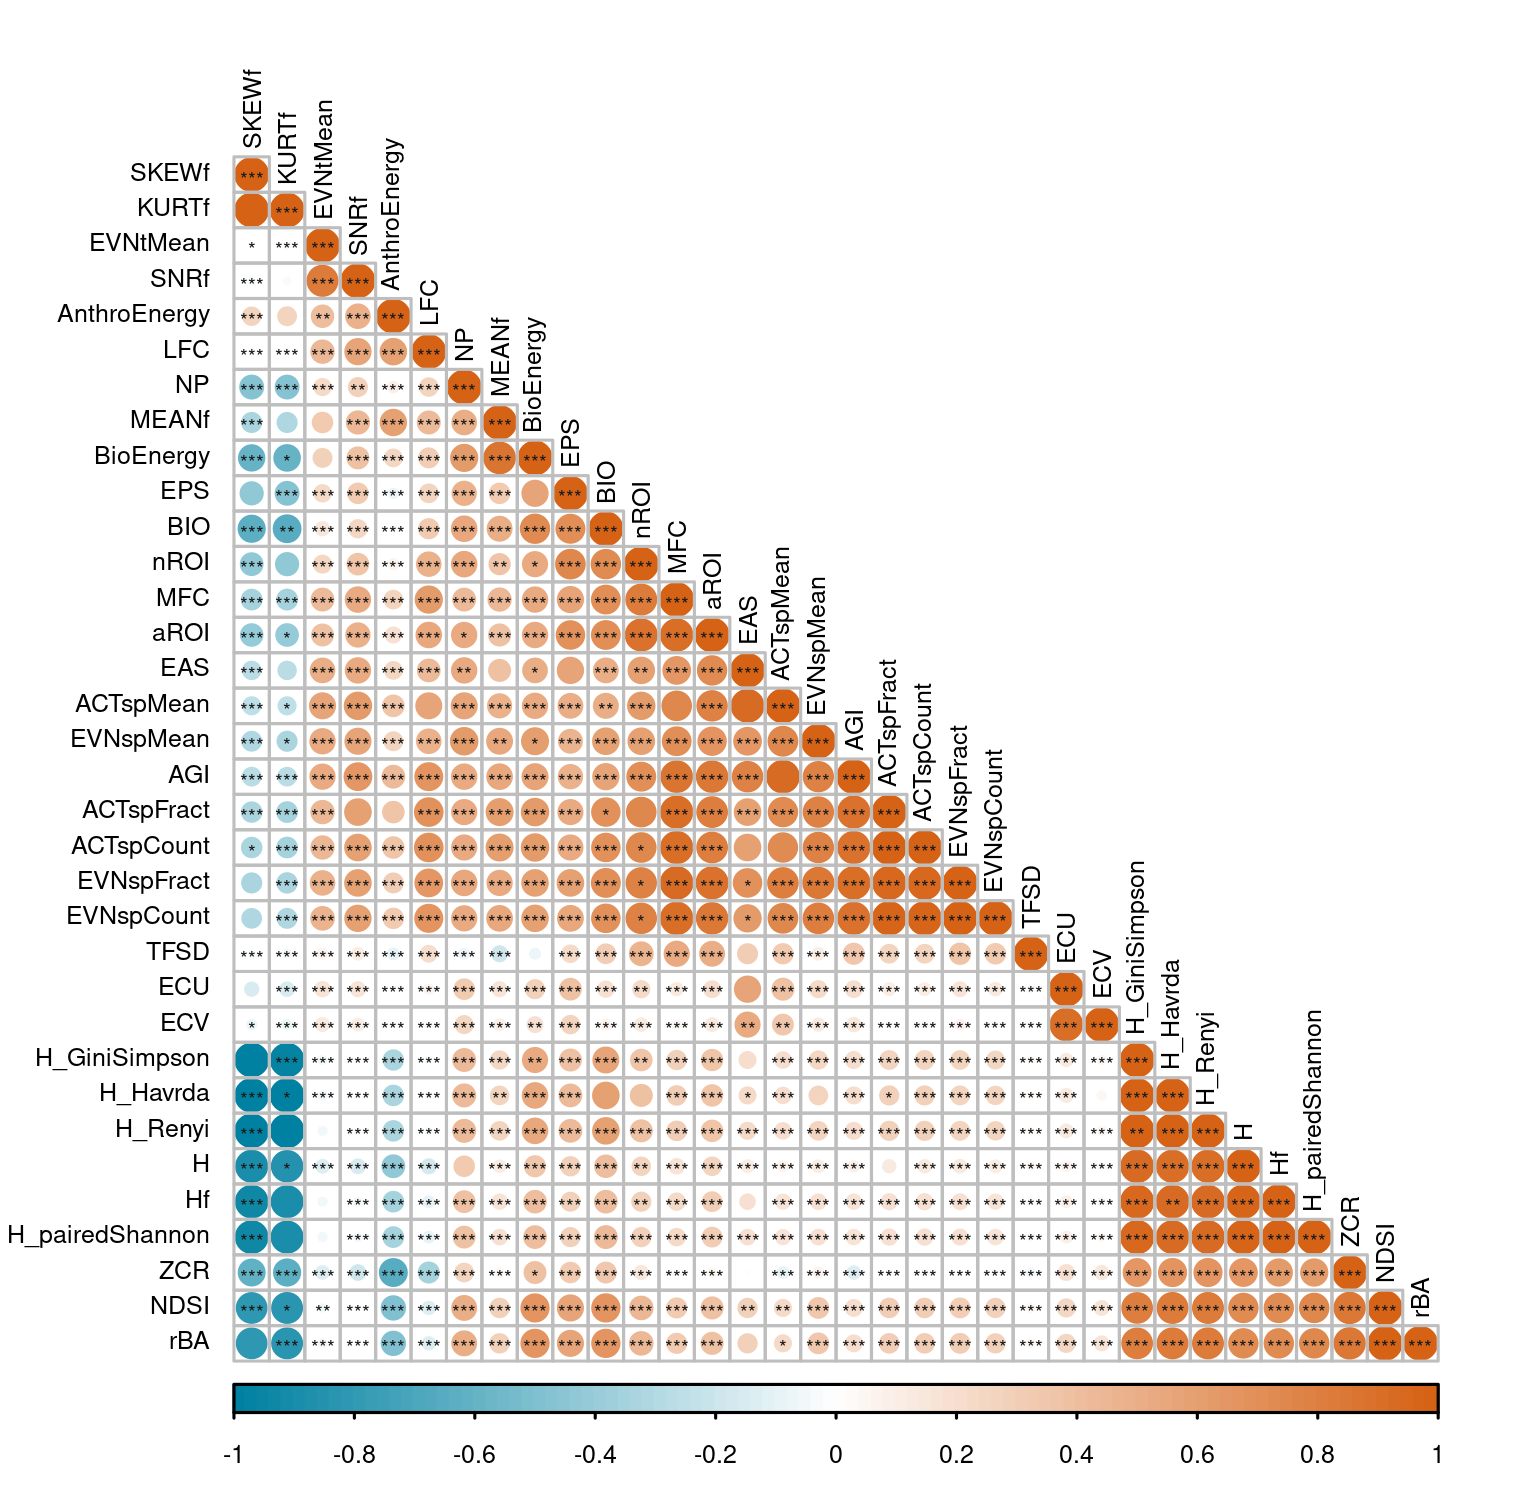

In [29]:
# select the columns by their name
data_index_selection = data_index[, c('ZCR'
                                    , 'EVNtMean'
                                    , 'MEANf'
                                    , 'SKEWf'
                                    , 'KURTf'
                                    , 'NP'
                                    , 'SNRf'
                                    , 'Hf'
                                    , 'H'
                                    , 'EAS'
                                    , 'ECU'
                                    , 'ECV'
                                    , 'EPS'
                                    , 'NDSI'
                                    , 'rBA'
                                    , 'AnthroEnergy'
                                    , 'BioEnergy'
                                    , 'BIO'
                                    , 'LFC'
                                    , 'MFC'
                                    , 'ACTspFract'
                                    , 'ACTspCount'
                                    , 'ACTspMean'
                                    , 'EVNspFract'
                                    , 'EVNspMean'
                                    , 'EVNspCount'
                                    , 'TFSD'
                                    , 'H_Havrda'
                                    , 'H_Renyi'
                                    , 'H_pairedShannon'
                                    , 'H_GiniSimpson'
                                    , 'AGI'
                                    , 'nROI'
                                    , 'aROI')]

# Resize the figure 
options(repr.plot.width = 5.1, repr.plot.height = 5, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index_selection
                  , method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index_selection, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.4, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 90,
      tl.cex = 0.5,
      cl.ratio = 0.1,
      cl.cex = 0.5
)


In [30]:
# Find the indices of correlations with abs(R) > 0.75 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.75 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
      indice1 = rownames(cor_matrix)[significant_idx[, 1]],
      indice2 = colnames(cor_matrix)[significant_idx[, 2]],
      correlation_r = cor_matrix[significant_idx],
      pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)

# print the unique indice1
print("=================================")
print("The unique indice1 (high multi-collinearity) are ")
print(unique(most_correlated_index$indice1))

[1] "================================="
[1] "The most correlated index are "


           indice1         indice2 correlation_r        pvalue
1              ZCR            NDSI     0.8506661  0.000000e+00
2              ZCR             rBA     0.8506661  3.154355e-47
3         EVNtMean            SNRf     0.8294075  8.175150e-43
4            MEANf       BioEnergy     0.8691542 2.527323e-141
5            SKEWf           KURTf     0.9925286  0.000000e+00
6            SKEWf              Hf    -0.9213534  0.000000e+00
7            SKEWf               H    -0.8905803  0.000000e+00
8            SKEWf            NDSI    -0.8105503 1.770265e-314
9            SKEWf             rBA    -0.8105503  2.864583e-09
10           SKEWf        H_Havrda    -0.9878435  0.000000e+00
11           SKEWf         H_Renyi    -0.9878435  0.000000e+00
12           SKEWf H_pairedShannon    -0.9261712  0.000000e+00
13           SKEWf   H_GiniSimpson    -0.9886731  0.000000e+00
14           KURTf              Hf    -0.8839284  0.000000e+00
15           KURTf               H    -0.8565112  0.000

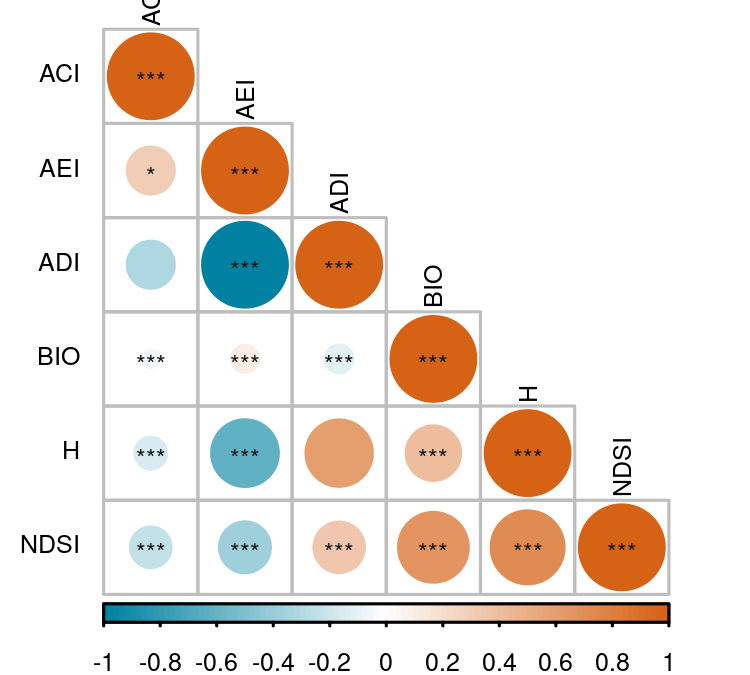

In [21]:
# select the columns by their name 
data_index_selection = data_index[,c("ACI", "H", "BIO", "NDSI","AEI", "ADI")]

# Resize the figure 
options(repr.plot.width = 2.5, repr.plot.height = 2.25, repr.plot.res = 300)

# change the color of the plot
col = colorRampPalette(c("#0081a1b0", "white", "#d66215c5"))(100)

# Compute the correlation matrix
cor_matrix = cor(data_index_selection, method=CORRELATION_TYPE, use="pairwise.complete.obs")
# compute the statistics and pvalue
pvalue_matrix = cor.mtest(data_index_selection, conf.level = 0.95)$p

# plot the correlation matrix with the pvalue
corrplot(
      cor_matrix,
      p.mat = pvalue_matrix,
      type = 'lower',
      method = 'circle',
      order = 'hclust',
      addrect = 2,
      insig = 'label_sig',
      sig.level = c(0.001, 0.01, 0.05),
      col = col,
      pch.cex = 0.5, 
      pch.col = 'grey10',
      tl.col = 'black',
      tl.srt = 90,
      tl.cex = 0.5,
      cl.ratio = 0.15,
      cl.cex = 0.5
)

In [22]:
# Find the indices of correlations with abs(R) > 0.90 and p-value < 0.001
significant_idx <- which(abs(cor_matrix) > 0.90 & pvalue_matrix < 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
significant_idx <- unique(t(apply(significant_idx, 1, sort)))

# Extract parameters based on significant indices
most_correlated_index <- data.frame(
  indice1 = rownames(cor_matrix)[significant_idx[, 1]],
  indice2 = colnames(cor_matrix)[significant_idx[, 2]],
  correlation_r = cor_matrix[significant_idx],
  pvalue = pvalue_matrix[significant_idx]
)

print("=================================")
print("The most correlated index are ")
print(most_correlated_index)

[1] "================================="
[1] "The most correlated index are "
  indice1 indice2 correlation_r pvalue
1     AEI     ADI    -0.9989378      0


In [23]:
# Find the indices of correlations with abs(R) < 0.1 and p-value > 0.001
nonsignificant_idx <- which(abs(cor_matrix) < 0.10 & pvalue_matrix > 0.001 & row(cor_matrix) != col(cor_matrix), arr.ind = TRUE)

# Remove duplicates (e.g., row=7, col=1 and col=7, row=1)
nonsignificant_idx <- unique(t(apply(nonsignificant_idx, 1, sort)))

# Extract parameters based on significant indices
less_correlated_index <- data.frame(
  indice1 = rownames(cor_matrix)[nonsignificant_idx[, 1]],
  indice2 = colnames(cor_matrix)[nonsignificant_idx[, 2]],
  correlation_r = cor_matrix[nonsignificant_idx],
  pvalue = pvalue_matrix[nonsignificant_idx]
)

print("=================================")
print("The less correlated index are ")
print(less_correlated_index)

[1] "================================="
[1] "The less correlated index are "
  indice1 indice2 correlation_r    pvalue
1     ACI     BIO   -0.04367623 0.5409671
